Dataset shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


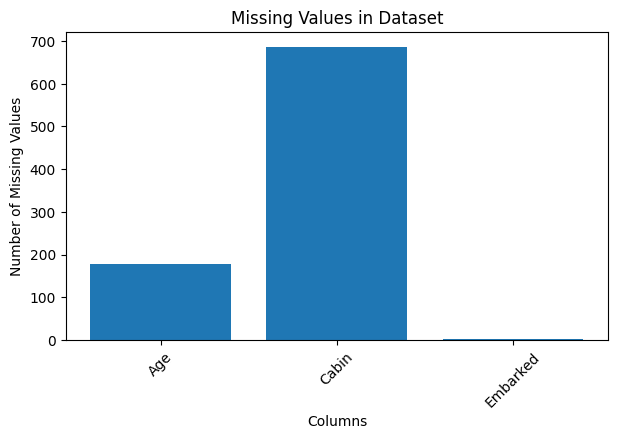

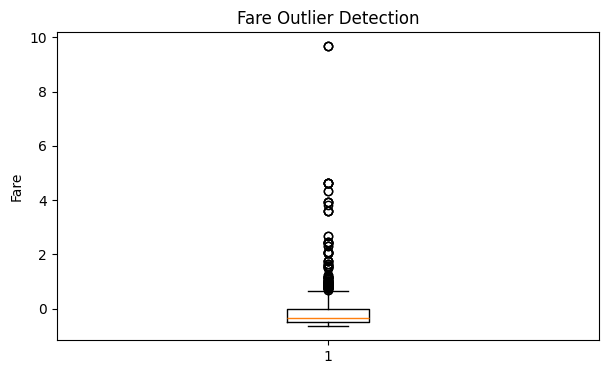

Final dataset shape: (775, 13)
Preprocessing completed successfully ✅


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_Size,Is_Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.565736,1,0,A/5 21171,-0.502445,S,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,-0.258337,0,0,STON/O2. 3101282,-0.488854,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.433312,1,0,113803,0.420730,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,0.433312,0,0,373450,-0.486337,S,1,1
5,6,0,3,"Moran, Mr. James",male,-0.104637,0,0,330877,-0.478116,Q,1,1


In [32]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler


# Load dataset

df = pd.read_csv("data/titanic.csv")

df.head()

# Basic dataset exploration

print("Dataset shape:", df.shape)

df.info()

df.isnull().sum()

# Visualize missing values

missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(7,4))

plt.bar(missing.index, missing.values)

plt.title("Missing Values in Dataset")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.show()

# Handling missing values

# Replace Age missing values with median

df["Age"] = df["Age"].fillna(df["Age"].median())


# Replace Embarked missing values with most frequent value

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


# Remove Cabin because most values are missing

df.drop("Cabin", axis=1, inplace=True)


# Verify missing values

df.isnull().sum()

# Feature engineering

# Create a new feature for total family members

df["Family_Size"] = df["SibSp"] + df["Parch"] + 1


# Identify passengers travelling alone

df["Is_Alone"] = (df["Family_Size"] == 1).astype(int)


df.head()

# Feature scaling

scaler = StandardScaler()

df[["Age", "Fare"]] = scaler.fit_transform(
    df[["Age", "Fare"]]
)


df.head()

# Detect outliers using boxplot

plt.figure(figsize=(7,4))

plt.boxplot(df["Fare"])

plt.title("Fare Outlier Detection")

plt.ylabel("Fare")

plt.show()

# Removing outliers using IQR method

Q1 = df["Fare"].quantile(0.25)

Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1


df = df[
    (df["Fare"] >= Q1 - 1.5 * IQR) &
    (df["Fare"] <= Q3 + 1.5 * IQR)
]


print("Final dataset shape:", df.shape)

# Save processed dataset

df.to_csv(
    "titanic_preprocessed_final.csv",
    index=False
)


print("Preprocessing completed successfully ✅")


df.head()
